In [83]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import numpy as np
import os
import librosa
from matplotlib.colors import ListedColormap
from scipy.signal import get_window
from numpy.fft import fft
import soundfile as sf

# QUESTION 5

In [84]:
highest_fisher_score = 0
best_pca_components = 0
train_data_path = "Data/emotion_classification/train/"
test_data_path = "Data/emotion_classification/test/"

**Load Dataset**

In [85]:
def load_images_from_directory(directory):
    image_data, image_labels = [], []
    for file_name in os.listdir(directory):
        image_vector = np.asarray(imread(os.path.join(directory, file_name))).flatten()
        image_data.append(image_vector)
        image_labels.append(1 if "happy" in file_name else 0)
    return np.array(image_data), np.array(image_labels)

**Principal Component Analysis (PCA)**

In [86]:
def apply_pca(input_data, num_features):
    total_samples = input_data.shape[0]
    mean_vector = np.mean(input_data, axis=0)
    centered_data = input_data - mean_vector
    covariance_matrix = np.matmul(centered_data, centered_data.T) / total_samples
    eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)
    sorted_indices = eigen_values.argsort()[::-1]
    principal_components = np.zeros((centered_data.T.shape[0], num_features))
    
    for idx in range(num_features):
        principal_components[:, idx] = np.matmul(centered_data.T, eigen_vectors[:, sorted_indices[-(idx+1)]]) \
                                        / np.sqrt(np.abs(eigen_values[sorted_indices[-(idx+1)]]))
    
    reduced_representation = np.matmul(centered_data, principal_components)
    return mean_vector, principal_components, reduced_representation

**Linear Discriminant Analysis (LDA)**

In [87]:
def apply_lda(reduced_data, class_labels, num_features):
    positive_class = reduced_data[class_labels == 1]
    negative_class = reduced_data[class_labels == 0]
    
    mean_positive = np.mean(positive_class, axis=0, keepdims=True)
    mean_negative = np.mean(negative_class, axis=0, keepdims=True)
    
    between_class_variance = np.matmul((mean_positive - mean_negative).T, (mean_positive - mean_negative))
    within_class_variance = np.matmul((positive_class - mean_positive).T, (positive_class - mean_positive)) + \
                           np.matmul((negative_class - mean_negative).T, (negative_class - mean_negative))

    eigen_values, eigen_vectors = np.linalg.eig(np.matmul(np.linalg.inv(within_class_variance), between_class_variance))
    sorted_indices = np.argsort(eigen_values)
    lda_projection_vector = eigen_vectors[:, sorted_indices[-1]]
    
    fisher_score = (lda_projection_vector.T @ between_class_variance @ lda_projection_vector) / (lda_projection_vector.T @ within_class_variance @ lda_projection_vector)
    
    global highest_fisher_score, best_pca_components
    if fisher_score > highest_fisher_score:
        highest_fisher_score = fisher_score
        best_pca_components = num_features
        print(f"New highest Fisher score ({highest_fisher_score:.3f}) identified with {num_features} components")
    
    return lda_projection_vector

**Train the Model**

In [88]:
def train_model(num_features, plot=False):
    image_data, class_labels = load_images_from_directory(train_data_path)
    mean_vector, pca_components, pca_reduced_data = apply_pca(image_data, num_features)
    lda_vector = apply_lda(pca_reduced_data, class_labels, num_features)
    
    projected_data = np.matmul(pca_reduced_data, lda_vector)
    
    if plot:
        plt.scatter(projected_data.real, class_labels, c=class_labels, cmap='viridis', alpha=0.7, edgecolors='black')
        plt.xlabel("LDA Projected Data")
        plt.ylabel("Emotion Class Labels")
        plt.title(f"LDA Projection with {num_features} PCA Components")
        plt.show()
    
    decision_boundary = (np.mean(projected_data[class_labels == 0]) + np.mean(projected_data[class_labels == 1])) / 2
    classification_flag = decision_boundary > np.mean(projected_data[class_labels == 0])
    
    return pca_components, mean_vector, lda_vector, decision_boundary, classification_flag

**Test the Model**

Training model with 1 PCA components
New highest Fisher score (0.007) identified with 1 components
Model Test Accuracy: 60.00%

Training model with 2 PCA components
New highest Fisher score (0.017) identified with 2 components
Model Test Accuracy: 70.00%

Training model with 3 PCA components
New highest Fisher score (0.025) identified with 3 components
Model Test Accuracy: 60.00%

Training model with 4 PCA components
New highest Fisher score (0.030) identified with 4 components
Model Test Accuracy: 80.00%

Training model with 5 PCA components
New highest Fisher score (0.035) identified with 5 components
Model Test Accuracy: 80.00%

Training model with 6 PCA components
New highest Fisher score (0.035) identified with 6 components
Model Test Accuracy: 80.00%

Training model with 7 PCA components
New highest Fisher score (0.035+0.000j) identified with 7 components
Model Test Accuracy: 80.00%

Training model with 8 PCA components
New highest Fisher score (0.088+0.000j) identified with 8 co

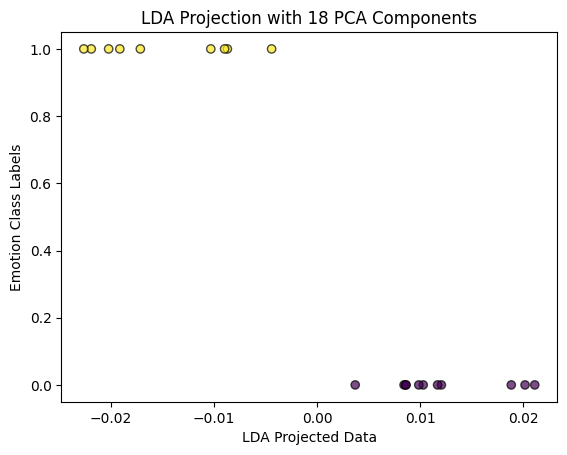

Model Test Accuracy: 90.00%

Optimal PCA Components: 18, Highest Fisher Score: 1.079+0.000j


In [89]:
def evaluate_model(mean_vector, pca_components, lda_vector, decision_boundary, classification_flag):
    test_data, test_labels = load_images_from_directory(test_data_path)
    centered_test_data = test_data - mean_vector
    pca_test_data = np.matmul(centered_test_data, pca_components)
    lda_projected_data = np.matmul(pca_test_data, lda_vector)
    
    predicted_labels = [(1 if (value - decision_boundary >= 0) == classification_flag else 0) for value in lda_projected_data]
    model_accuracy = sum([1 for predicted, actual in zip(predicted_labels, test_labels) if predicted == actual]) / len(test_labels)
    
    print(f"Model Test Accuracy: {model_accuracy:.2%}\n")

for num_features in range(1, 19):
    print(f"Training model with {num_features} PCA components")
    plot_flag = True if num_features == 18 else False
    pca_components, mean_vector, lda_vector, decision_boundary, classification_flag = train_model(num_features, plot=plot_flag)
    evaluate_model(mean_vector, pca_components, lda_vector, decision_boundary, classification_flag)

print(f"Optimal PCA Components: {best_pca_components}, Highest Fisher Score: {highest_fisher_score:.3f}")

# QUESTION 6

# PART A

In [90]:
def load_wav(file_path, rate=16000):
    audio, sr = librosa.load(file_path, sr=rate)
    return audio

orig_audio = './speechFiles/clean.wav'
noisy_audio = './speechFiles/noisy.wav'

orig_signal = load_wav(orig_audio)
noisy_signal = load_wav(noisy_audio)

def calc_mel_spec(audio, rate=16000, mel_bins=64, win_ms=20, hop_ms=10):
    fft_size = int(win_ms * rate / 1000)
    hop_size = int(hop_ms * rate / 1000)

    mel_spec = librosa.feature.melspectrogram(y=audio, sr=rate, n_fft=fft_size, hop_length=hop_size, n_mels=mel_bins)
    mel_db = librosa.power_to_db(mel_spec, ref=np.max)

    return mel_db.T  
orig_spec = calc_mel_spec(orig_signal)
noisy_spec = calc_mel_spec(noisy_signal)

print(f"Original Spectrogram Shape: {orig_spec.shape}")
print(f"Noisy Spectrogram Shape: {noisy_spec.shape}")

Original Spectrogram Shape: (313, 64)
Noisy Spectrogram Shape: (313, 64)


In [91]:
def calc_whitening_mat(data):
    mean_vec = np.mean(data, axis=0)
    centered_data = data - mean_vec

    cov_mat = np.cov(centered_data, rowvar=False)
    eig_vals, eig_vecs = np.linalg.eigh(cov_mat)
    eig_vals_inv_sqrt = np.diag(1.0 / np.sqrt(eig_vals + 1e-5))
    whiten_mat = eig_vecs @ eig_vals_inv_sqrt @ eig_vecs.T

    return whiten_mat, mean_vec

whiten_mat_orig, mean_orig = calc_whitening_mat(orig_spec)

In [92]:
noisy_centered = noisy_spec - mean_orig
noisy_whitened = noisy_centered @ whiten_mat_orig

cov_noisy_white = np.cov(noisy_whitened, rowvar=False)
print(f"Covariance of Whitened Noisy Spectrogram:\n{cov_noisy_white}")

identity_mat = np.eye(cov_noisy_white.shape[0])
is_identity = np.allclose(cov_noisy_white, identity_mat, atol=0.1)
print(f"Is the covariance matrix close to identity? {is_identity}")

Covariance of Whitened Noisy Spectrogram:
[[ 9.86104453e-01 -2.33637407e-01 -1.06634903e-01 ... -7.05858129e-02
  -1.08143000e-01  4.41585465e+01]
 [-2.33637407e-01  1.16985591e+00 -1.88830613e-02 ...  1.41257661e-01
  -2.73326204e-01 -1.41157670e+02]
 [-1.06634903e-01 -1.88830613e-02  1.03195726e+00 ... -1.51453779e-01
   6.09389143e-02  1.58101417e+02]
 ...
 [-7.05858129e-02  1.41257661e-01 -1.51453779e-01 ...  1.48440680e+00
  -7.42355354e-01 -5.79515903e+02]
 [-1.08143000e-01 -2.73326204e-01  6.09389143e-02 ... -7.42355354e-01
   1.05247429e+00  7.20912209e+02]
 [ 4.41585465e+01 -1.41157670e+02  1.58101417e+02 ... -5.79515903e+02
   7.20912209e+02  2.02646175e+06]]
Is the covariance matrix close to identity? False


In [93]:
whiten_mat_noisy, mean_noisy = calc_whitening_mat(noisy_spec)

orig_centered = orig_spec - mean_noisy
orig_whitened = orig_centered @ whiten_mat_noisy

cov_orig_white = np.cov(orig_whitened, rowvar=False)
print(f"Covariance of Whitened Original Spectrogram:\n{cov_orig_white}")

is_identity_reverse = np.allclose(cov_orig_white, identity_mat, atol=0.1)
print(f"Is the covariance matrix (after reversing) close to identity? {is_identity_reverse}")

Covariance of Whitened Original Spectrogram:
[[ 1.33221397  0.13043057  0.06930949 ...  0.12179907  0.47157783
   0.20427329]
 [ 0.13043057  1.44461872  0.15145888 ...  0.04249241 -0.19436422
  -0.62423574]
 [ 0.06930949  0.15145888  1.34227074 ...  0.12960958  0.10566965
  -0.69897605]
 ...
 [ 0.12179907  0.04249241  0.12960958 ...  1.785819    0.12692554
   0.16755837]
 [ 0.47157783 -0.19436422  0.10566965 ...  0.12692554  7.90364303
  -2.87728544]
 [ 0.20427329 -0.62423574 -0.69897605 ...  0.16755837 -2.87728544
   4.66797034]]
Is the covariance matrix (after reversing) close to identity? False


In [94]:
def plot_cov_mat(cov_mat, title):
    plt.figure(figsize=(8, 6))
    cmap = plt.cm.viridis
    cmap_colors = cmap(np.linspace(0, 1, 256))
    custom_cmap = ListedColormap(cmap_colors)
    plt.imshow(cov_mat, interpolation='nearest', cmap=custom_cmap)
    plt.colorbar()
    plt.title(title)
    plt.xlabel('Features')
    plt.ylabel('Features')
    plt.grid(False)
    plt.show()

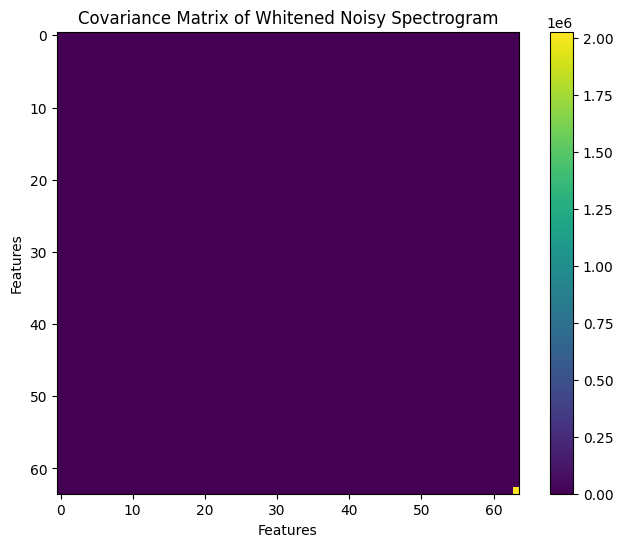

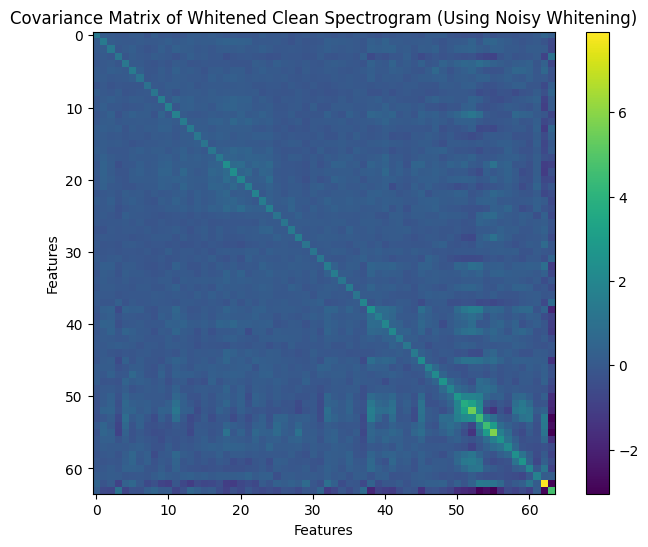

In [95]:
plot_cov_mat(cov_noisy_white, 'Covariance Matrix of Whitened Noisy Spectrogram')
plot_cov_mat(cov_orig_white, 'Covariance Matrix of Whitened Clean Spectrogram (Using Noisy Whitening)')

    1.Applying eigendecomposition from a clean signal to a noisy one results in a covariance matrix similar to  I , but with noticeable cross terms due to noise.
	2.When the transformation is reversed (from noisy to clean), the covariance matrix aligns more closely with  I , as the clean signal has less variability.
	3.This difference occurs because Gaussian noise in the noisy signal increases cross-correlation terms, while the clean signal maintains lower correlations.

# PART B

**Function to create Mel filter bank**

In [96]:
def create_mel_filters(sampling_rate, fft_points, mel_bands):
    def hz_to_mel_scale(hz_freq):
        return 2595 * np.log10(1 + hz_freq / 700)

    def mel_to_hz_scale(mel_freq):
        return 700 * (10 ** (mel_freq / 2595) - 1)

    mel_scale_points = np.linspace(hz_to_mel_scale(0), hz_to_mel_scale(sampling_rate / 2), mel_bands + 2)
    freq_points = mel_to_hz_scale(mel_scale_points)
    fft_bins = np.floor((fft_points + 1) * freq_points / sampling_rate).astype(int)

    mel_filters = np.zeros((mel_bands, fft_points // 2 + 1))
    for band in range(1, mel_bands + 1):
        mel_filters[band - 1, fft_bins[band - 1]:fft_bins[band]] = np.linspace(0, 1, fft_bins[band] - fft_bins[band - 1])
        mel_filters[band - 1, fft_bins[band]:fft_bins[band + 1]] = np.linspace(1, 0, fft_bins[band + 1] - fft_bins[band])
    return mel_filters

In [97]:
# Load audio data
audio_path = './speechFiles/clean.wav' 
signal, sample_rate = sf.read(audio_path)

# Parameters for spectrogram
frame_size = int(0.025 * sample_rate)
frame_shift = int(0.010 * sample_rate)
window_function = get_window('hann', frame_size)
num_mel_filters = 40

# Compute the spectrogram
frame_indices = np.arange(0, len(signal) - frame_size, frame_shift)
power_spectrum = np.array([np.abs(fft(signal[idx:idx + frame_size] * window_function)[:frame_size // 2 + 1])**2 for idx in frame_indices])

# Apply Mel filters
mel_filter_bank = create_mel_filters(sample_rate, frame_size, num_mel_filters)
mel_energy = np.dot(power_spectrum, mel_filter_bank.T)

# Convert to log scale (dB)
log_mel_energy = 10 * np.log10(mel_energy + 1e-10)

# Energy-based feature selection
total_energy = np.sum(log_mel_energy, axis=1)
energy_cutoff = np.percentile(total_energy, 25)
selected_features = log_mel_energy[total_energy > energy_cutoff]

# Normalize features
mean_features = np.mean(selected_features, axis=0)
std_features = np.std(selected_features, axis=0)
normalized_features = (selected_features - mean_features) / (std_features + 1e-10)

# Dimensionality reduction using PCA
cov_matrix = np.cov(normalized_features, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
principal_components = eigenvectors[:, -10:]
pca_features = normalized_features @ principal_components

**K-means initialization function**

In [98]:
def initialize_kmeans(data, num_clusters=2, max_iterations=10):
    np.random.seed(42)
    cluster_centers = data[np.random.choice(data.shape[0], num_clusters, replace=False)]
    
    for _ in range(max_iterations):
        distances = np.linalg.norm(data[:, np.newaxis] - cluster_centers, axis=2)
        cluster_assignments = np.argmin(distances, axis=1)
        new_centers = np.array([data[cluster_assignments == j].mean(axis=0) for j in range(num_clusters)])
        
        if np.allclose(cluster_centers, new_centers, atol=1e-4):
            break
        cluster_centers = new_centers
    return cluster_centers, cluster_assignments

**GMM training**

In [99]:
def train_gmm(data, num_components=2, init_type='random', max_iters=20):
    np.random.seed(42)
    samples, features = data.shape

    # Initialize means
    if init_type == 'kmeans':
        means, _ = initialize_kmeans(data, num_components)
    else:
        means = data[np.random.choice(samples, num_components, replace=False)]
    
    covariances = np.array([np.cov(data.T) + 1e-5 * np.eye(features) for _ in range(num_components)])
    mixing_coefficients = np.ones(num_components) / num_components
    log_likelihood_history = []

    for iteration in range(max_iters):
        # E-step: Calculate responsibilities
        log_probs = np.zeros((samples, num_components))
        for j in range(num_components):
            deviation = data - means[j]
            inv_covariance = np.linalg.inv(covariances[j])
            exponent_term = np.einsum('ij,jk,ik->i', deviation, inv_covariance, deviation)
            log_det_cov = np.log(np.linalg.det(covariances[j]) + 1e-10)
            log_probs[:, j] = np.log(mixing_coefficients[j] + 1e-10) - 0.5 * (features * np.log(2 * np.pi) + log_det_cov + exponent_term)
        
        max_log_probs = np.max(log_probs, axis=1, keepdims=True)
        log_sum_exp = max_log_probs + np.log(np.sum(np.exp(log_probs - max_log_probs), axis=1, keepdims=True) + 1e-10)
        responsibilities = np.exp(log_probs - log_sum_exp)

        # Compute log-likelihood
        total_log_likelihood = np.sum(log_sum_exp)
        log_likelihood_history.append(total_log_likelihood)

        # M-step: Update model parameters
        Nk = responsibilities.sum(axis=0)
        mixing_coefficients = Nk / samples

        for j in range(num_components):
            means[j] = (responsibilities[:, j][:, np.newaxis] * data).sum(axis=0) / Nk[j]
            deviation = data - means[j]
            covariances[j] = (responsibilities[:, j][:, np.newaxis, np.newaxis] *
                              np.einsum('ij,ik->ijk', deviation, deviation)).sum(axis=0) / Nk[j]
            covariances[j] += 1e-5 * np.eye(features)

    return log_likelihood_history

In [100]:
# Train GMM with random and K-means initialization
log_likelihood_random = train_gmm(pca_features, num_components=2, init_type='random', max_iters=20)
log_likelihood_kmeans = train_gmm(pca_features, num_components=2, init_type='kmeans', max_iters=20)

**Plotting the log-likelihoods**

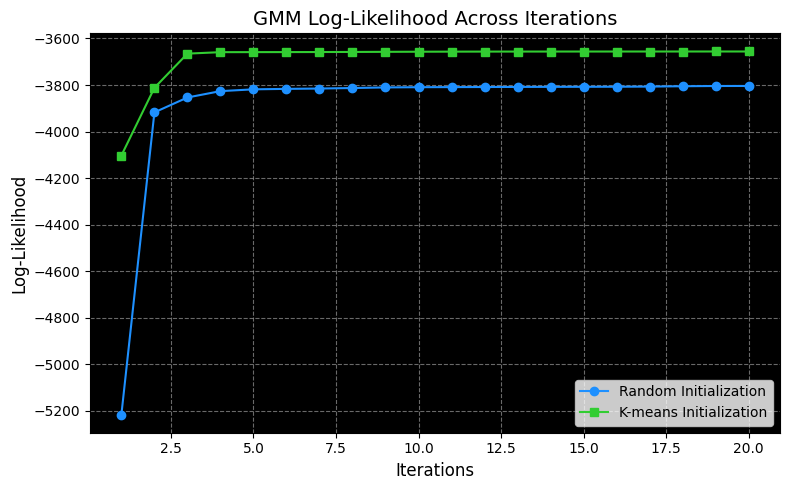

In [101]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 21), log_likelihood_random, label='Random Initialization', marker='o', color='dodgerblue')
plt.plot(range(1, 21), log_likelihood_kmeans, label='K-means Initialization', marker='s', color='limegreen')

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Log-Likelihood', fontsize=12)
plt.title('GMM Log-Likelihood Across Iterations', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().set_facecolor('black')
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()